In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.shapereader import Reader
import matplotlib.pyplot as plt
import geopandas as gpd


In [2]:
import os
root_proj = '/Users/luo/OneDrive/GitHub/High-Moutain-Asia-GIS-Data' ### your repo directory
os.chdir(root_proj)

In [3]:
path_rgi60_13 = 'glaciers/rgi60_13.gpkg'   ## Cental Asia
path_rgi60_14 = 'glaciers/rgi60_14.gpkg'   ## South Asia (West)
path_rgi60_15 = 'glaciers/rgi60_15.gpkg'   ## South Asia (East)
path_hma_holch2019 = 'extents/HMA/hma_bolch2019_subregions.gpkg' 


In [4]:
## check data
rgi60_13, rgi60_14, rgi60_15 = gpd.read_file(path_rgi60_13), gpd.read_file(path_rgi60_14), gpd.read_file(path_rgi60_15)


In [5]:
print('Attributes of the rgi6.0 data:\n', list(rgi60_13.keys()))
# rgi60_13.head(1)

Attributes of the rgi6.0 data:
 ['RGIId', 'GLIMSId', 'BgnDate', 'EndDate', 'CenLon', 'CenLat', 'O1Region', 'O2Region', 'Area', 'Zmin', 'Zmax', 'Zmed', 'Slope', 'Aspect', 'Lmax', 'Status', 'Connect', 'Form', 'TermType', 'Surging', 'Linkages', 'Name', 'geometry']


In [6]:
print('Number of the glaciers:')
print('rgi60_13:', rgi60_13.shape[0], 'rgi60_14:', rgi60_14.shape[0], 'rgi60_15:',rgi60_15.shape[0]); 
print('Area of the glaciers:')
print('rgi60_13: %.3f' % rgi60_13.Area.sum(), 'rgi60_14: %.3f' % rgi60_14.Area.sum(), 'rgi60_15: %.3f' % rgi60_15.Area.sum())


Number of the glaciers:
rgi60_13: 54429 rgi60_14: 27988 rgi60_15: 13119
Area of the glaciers:
rgi60_13: 49303.415 rgi60_14: 33568.298 rgi60_15: 14734.204


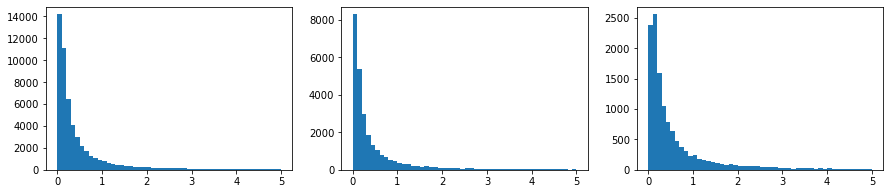

In [7]:
plt.figure(figsize=(15,3))
plt.subplot(1,3,1)
n_13, bins_13, patches_13 = plt.hist(rgi60_13.Area, bins=50, range=(0, 5))
plt.subplot(1,3,2)
n_14, bins_14, patches_14 = plt.hist(rgi60_14.Area, bins=50, range=(0, 5))
plt.subplot(1,3,3)
n_15, bins_15, patches_15 = plt.hist(rgi60_15.Area, bins=50, range=(0, 5))


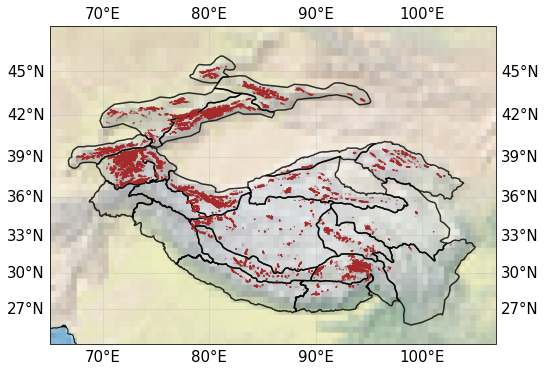

In [9]:
warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size':15})

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1,1,1,projection=ccrs.Mercator())

ax.set_extent([65.0, 107.0, 24.0, 46.0])
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, zorder=1)
fea_hma_holch2019 = cfeature.ShapelyFeature(Reader(path_hma_holch2019).geometries(),\
                            crs=ccrs.PlateCarree(), edgecolor='black', alpha=0.8,\
                            linestyle='-', linewidth=1.5, facecolor='none')

fea_rgi60_13 = cfeature.ShapelyFeature(Reader(path_rgi60_13).geometries(),\
                            crs=ccrs.PlateCarree(), edgecolor='Brown', alpha=0.8,\
                            linestyle='-', linewidth=1, facecolor='none')    
fea_rgi60_14 = cfeature.ShapelyFeature(Reader(path_rgi60_14).geometries(),\
                            crs=ccrs.PlateCarree(), edgecolor='Green', alpha=0.8,\
                            linestyle='-', linewidth=1, facecolor='none') 
fea_rgi60_15 = cfeature.ShapelyFeature(Reader(path_rgi60_15).geometries(),\
                            crs=ccrs.PlateCarree(), edgecolor='Blue', alpha=0.8,\
                            linestyle='-', linewidth=1, facecolor='none')

ax.add_feature(fea_hma_holch2019, zorder=2)
ax.add_feature(fea_rgi60_13, zorder=2)   ### !!!very time consuming
# ax.add_feature(fea_rgi60_14, zorder=2)   ### !!!very time consuming
# ax.add_feature(fea_rgi60_15, zorder=2)  ### !!!very time consuming
ax.stock_img(); ax.coastlines()

